In [1]:
from backend.graph import support_agent
from langchain_core.messages import HumanMessage

/Users/ayush/Documents/taskflow-support-agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


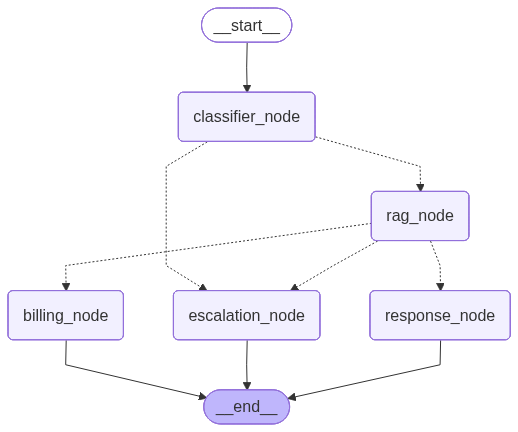

In [2]:
support_agent

In [3]:
# test 1
config = {"configurable": {"thread_id": "test-1"}}

result = support_agent.invoke(
    {"messages": [HumanMessage(content="How do I create a new project in TaskFlow?")]},
    config=config,
)

print("Intent:", result.get("intent"))
print("Confidence:", result.get("confidence"))
print("Response:", result["messages"][-1].content)

Intent: faq
Confidence: 0.772070706
Response: To create a new project in TaskFlow, follow these steps:

1. Click "+ New Project" from the sidebar.
2. Choose a template (Kanban, Sprint Board, Simple List) or start with a blank project.
3. Name your project and optionally add a description.
4. Set the project visibility to either "Workspace" (all members can see) or "Private" (invite-only).

Once your project is created, you'll see your empty board. You can start by creating lists (columns) such as "To Do," "In Progress," and "Done," and then add tasks to each list.

If you have any more questions or need further assistance, feel free to ask!


In [4]:
result

{'messages': [HumanMessage(content='How do I create a new project in TaskFlow?', additional_kwargs={}, response_metadata={}, id='f08462df-20cf-4e96-9b34-695e42326cb5'),
  AIMessage(content='To create a new project in TaskFlow, follow these steps:\n\n1. Click "+ New Project" from the sidebar.\n2. Choose a template (Kanban, Sprint Board, Simple List) or start with a blank project.\n3. Name your project and optionally add a description.\n4. Set the project visibility to either "Workspace" (all members can see) or "Private" (invite-only).\n\nOnce your project is created, you\'ll see your empty board. You can start by creating lists (columns) such as "To Do," "In Progress," and "Done," and then add tasks to each list.\n\nIf you have any more questions or need further assistance, feel free to ask!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 458, 'total_tokens': 599, 'completion_tokens_details': {'accepted_prediction_tok

In [5]:
# Test 2: Technical
config2 = {"configurable": {"thread_id": "test-5"}}
result2 = support_agent.invoke(
    {"messages": [HumanMessage(content="My tasks aren't syncing between my phone and laptop")]},
    config=config2,
)
print("Intent:", result2.get("intent"))
print("Confidence:", result2.get("confidence"))
print("Response:", result2["messages"][-1].content)

Intent: technical
Confidence: 0.62962
Response: I'm sorry to hear you're having trouble with syncing, but I'm here to help! Here are some steps you can follow to resolve the issue:

1. **Check Internet Connection**: Ensure both your phone and laptop have a stable internet connection.

2. **Force a Manual Sync**:
   - On your laptop (web), press `Ctrl+Shift+R` to perform a hard refresh.
   - On your phone (mobile), pull down on any screen to force a manual sync.

3. **Verify Workspace**: Make sure both devices are viewing the same workspace, especially if you belong to multiple workspaces.

4. **Check TaskFlow Status**: Visit [status.taskflow.io](http://status.taskflow.io) to see if there are any ongoing service incidents or scheduled maintenance that might be affecting sync.

5. **Log Out and Back In**: Try logging out and then logging back in on both devices to force a full resync with the server.

If the issue persists after trying these steps, please let me know, and we can explore 

In [6]:
result2

{'messages': [HumanMessage(content="My tasks aren't syncing between my phone and laptop", additional_kwargs={}, response_metadata={}, id='bd9ee63b-30fd-4ffa-a3c3-bfe02c59d854'),
  AIMessage(content="I'm sorry to hear you're having trouble with syncing, but I'm here to help! Here are some steps you can follow to resolve the issue:\n\n1. **Check Internet Connection**: Ensure both your phone and laptop have a stable internet connection.\n\n2. **Force a Manual Sync**:\n   - On your laptop (web), press `Ctrl+Shift+R` to perform a hard refresh.\n   - On your phone (mobile), pull down on any screen to force a manual sync.\n\n3. **Verify Workspace**: Make sure both devices are viewing the same workspace, especially if you belong to multiple workspaces.\n\n4. **Check TaskFlow Status**: Visit [status.taskflow.io](http://status.taskflow.io) to see if there are any ongoing service incidents or scheduled maintenance that might be affecting sync.\n\n5. **Log Out and Back In**: Try logging out and th

In [7]:
# Test 3: Billing (this should hit interrupt)
config3 = {"configurable": {"thread_id": "test-3"}}
result3 = support_agent.invoke(
    {"messages": [HumanMessage(content="I want a refund, I bought the Pro plan 5 days ago")]},
    config=config3,
)
print("Intent:", result3.get("intent"))
print("Confidence:", result3.get("confidence"))
print("Interrupts:", result3.get("__interrupt__"))

Intent: billing
Confidence: 0.471567154
Interrupts: [Interrupt(value={'type': 'billing_approval', 'customer_message': 'I want a refund, I bought the Pro plan 5 days ago', 'proposed_action': '- **Action being requested:** Refund\n- **Relevant policy details:** According to the TaskFlow Refund Policy for Monthly Plans, a full refund is available within 14 days of purchase.\n- **Eligibility:** The request is eligible for a full refund since it is within the 14-day window.\n\n**Draft response to the customer:**\n\nHello,\n\nThank you for reaching out to TaskFlow support. As per our refund policy, you are eligible for a full refund since your purchase of the Pro plan was made 5 days ago, which is within the 14-day refund window.\n\nTo proceed with your refund, please follow these steps:\n1. Go to Workspace Settings → Billing → Subscription.\n2. Click "Request Refund."\n3. Select a reason for the refund (optional but appreciated).\n4. Confirm the request.\n\nAlternatively, you can email us a

In [8]:
result3

{'messages': [HumanMessage(content='I want a refund, I bought the Pro plan 5 days ago', additional_kwargs={}, response_metadata={}, id='c5b37bb3-0083-4bbc-9115-59cda59babe0')],
 'intent': 'billing',
 'retrieved_docs': ["[Source: TaskFlow Refund Policy > Monthly Plans]\n## Monthly Plans\n\n**Full refund within 14 days of purchase.** If you're not satisfied with TaskFlow Pro or Business within the first 14 days of your subscription, request a full refund — no questions asked.\n\nAfter 14 days, monthly plans are non-refundable for the current billing cycle. You can cancel at any time, and your plan will remain active until the end of the current billing period. You will not be charged for the next cycle.\n\n**Prorated refunds** are available if you downgrade mid-cycle after the 14-day window. The unused portion of the current month is credited to your TaskFlow account balance, which is applied to future charges. Account balance credits do not expire but are not redeemable for cash.",
  '[

In [ ]:
# resuming the billing with accepting
from langgraph.types import Command

result3_resumed = support_agent.invoke(
    Command(resume={"approved": "yes"}),
    config=config3,
)
print("Response:", result3_resumed["messages"][-1].content)

Response: - **Action being requested:** Refund
- **Relevant policy details:** According to the TaskFlow Refund Policy for Monthly Plans, a full refund is available within 14 days of purchase.
- **Eligibility:** The request is eligible for a full refund since it was made within 5 days of purchase, which is within the 14-day refund window.

**Draft response to the customer:**

Hello,

Thank you for reaching out to TaskFlow support. I understand that you would like a refund for your Pro plan purchase made 5 days ago. According to our refund policy, you are eligible for a full refund as your request falls within the 14-day window for monthly plans.

To proceed with your refund, please follow these steps:
1. Go to Workspace Settings → Billing → Subscription.
2. Click "Request Refund."
3. Select a reason for the refund (optional but appreciated).
4. Confirm the request.

Alternatively, you can email us at billing@taskflow.io with your workspace name and the email address associated with your

In [12]:
result3_resumed

{'messages': [HumanMessage(content='I want a refund, I bought the Pro plan 5 days ago', additional_kwargs={}, response_metadata={}, id='c5b37bb3-0083-4bbc-9115-59cda59babe0'),
  AIMessage(content='- **Action being requested:** Refund\n- **Relevant policy details:** According to the TaskFlow Refund Policy for Monthly Plans, a full refund is available within 14 days of purchase.\n- **Eligibility:** The request is eligible for a full refund since it was made within 5 days of purchase, which is within the 14-day refund window.\n\n**Draft response to the customer:**\n\nHello,\n\nThank you for reaching out to TaskFlow support. I understand that you would like a refund for your Pro plan purchase made 5 days ago. According to our refund policy, you are eligible for a full refund as your request falls within the 14-day window for monthly plans.\n\nTo proceed with your refund, please follow these steps:\n1. Go to Workspace Settings → Billing → Subscription.\n2. Click "Request Refund."\n3. Select

In [13]:
# resumed_with_rejection
config6 = {"configurable": {"thread_id": "test-6"}}
result6 = support_agent.invoke(
    {"messages": [HumanMessage(content="I want to cancel and get a refund for my annual plan, I bought it 3 months ago")]},
    config=config6,
)
print("Interrupts:", result6.get("__interrupt__")[0].value["proposed_action"])

# Reject it
result6_rejected = support_agent.invoke(
    Command(resume={"approved": "no"}),
    config=config6,
)
print("Response:", result6_rejected["messages"][-1].content)

Interrupts: **Requested Action:**
- The customer is requesting a cancellation and refund for their annual plan.

**Relevant Policy Details:**
- According to the TaskFlow Refund Policy for Annual Plans, a full refund is available within 30 days of purchase.
- After 30 days, annual plans are non-refundable. If canceled after 30 days, the plan remains active until the end of the annual billing period, and no partial refund is issued.

**Eligibility Based on Policy:**
- The customer's request for a refund is not eligible as it has been 3 months since the purchase, exceeding the 30-day refund window.

**Draft Response to the Customer:**

Dear [Customer Name],

Thank you for reaching out to TaskFlow support. I understand that you wish to cancel your annual plan and request a refund.

According to our refund policy, annual plans are eligible for a full refund only within 30 days of purchase. Since your purchase was made 3 months ago, it falls outside of this refund window, and unfortunately, 

In [9]:
# Test 4: Escalation
config4 = {"configurable": {"thread_id": "test-4"}}
result4 = support_agent.invoke(
    {"messages": [HumanMessage(content="This is ridiculous, nothing works, I want to talk to a human")]},
    config=config4,
)
print("Intent:", result4.get("intent"))
print("Response:", result4["messages"][-1].content)

Intent: escalation
Response: I'm going to connect you with a human agent who can better assist you. I've shared a summary of our conversation so you won't need to repeat yourself. A team member will be with you shortly.


In [10]:
result4

{'messages': [HumanMessage(content='This is ridiculous, nothing works, I want to talk to a human', additional_kwargs={}, response_metadata={}, id='5632b0eb-bf64-46bf-90fc-a96a749c812f'),
  AIMessage(content="I'm going to connect you with a human agent who can better assist you. I've shared a summary of our conversation so you won't need to repeat yourself. A team member will be with you shortly.", additional_kwargs={}, response_metadata={}, id='c4ec53b5-dbb2-436a-b256-3a87e3973f2e', tool_calls=[], invalid_tool_calls=[])],
 'intent': 'escalation',
 'escalation_reason': 'Classified as needing human intervention'}